In [ ]:
!pip install imbalanced-learn

In [ ]:
pip install streamlit pandas joblib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 71.5 MB/s eta 0:00:00



Koreksi: Mengisi 307 Missing Value
Nilai terbanyak (Mode) di Delivery_Complications adalah: Sepsis

Verifikasi Missing Values:
Birth_Weight_kg                 0
Gestational_Age_weeks           0
Maternal_Age_years              0
Antenatal_Visits                0
Delivery_Complications          0
Place_of_Delivery               0
Breastfeeding_Initiation_hrs    0
Neonatal_Outcome                0
dtype: int64
Langkah 1: Data Understanding dan Cek Awal
Jumlah Baris Data Awal: 500

Statistik Deskriptif:
        Birth_Weight_kg  Gestational_Age_weeks  Maternal_Age_years  \
count        500.000000             500.000000          500.000000   
unique              NaN                    NaN                 NaN   
top                 NaN                    NaN                 NaN   
freq                NaN                    NaN                 NaN   
mean           2.804160              34.262000           29.702000   
std            0.588659               4.039057            8.739677   
min

/tmp/ipython-input-1002924212.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Delivery_Complications'].fillna(mode_complication, inplace=True)


Model Decision Tree berhasil disimpan sebagai 'model_neonatal_dt.joblib'
Daftar Fitur berhasil disimpan sebagai 'feature_columns.joblib'
Label Encoder berhasil disimpan sebagai 'label_encoder.joblib'

Langkah 6: Evaluasi Model pada Data Ujian (Test)
Akurasi Model Decision Tree: 86.00%

Confusion Matrix:
[[98  7]
 [14 31]]

Classification Report:
              precision    recall  f1-score   support

       Alive       0.88      0.93      0.90       105
        Died       0.82      0.69      0.75        45

    accuracy                           0.86       150
   macro avg       0.85      0.81      0.83       150
weighted avg       0.86      0.86      0.86       150


Langkah 7: Interpretasi (Untuk Insight Kesehatan)
TOP 5 FAKTOR RISIKO TERPENTING:
Gestational_Age_weeks              0.352578
Birth_Weight_kg                    0.303725
Delivery_Complications_Asphyxia    0.254126
Maternal_Age_years                 0.046470
Antenatal_Visits                   0.028648
dtype: float64


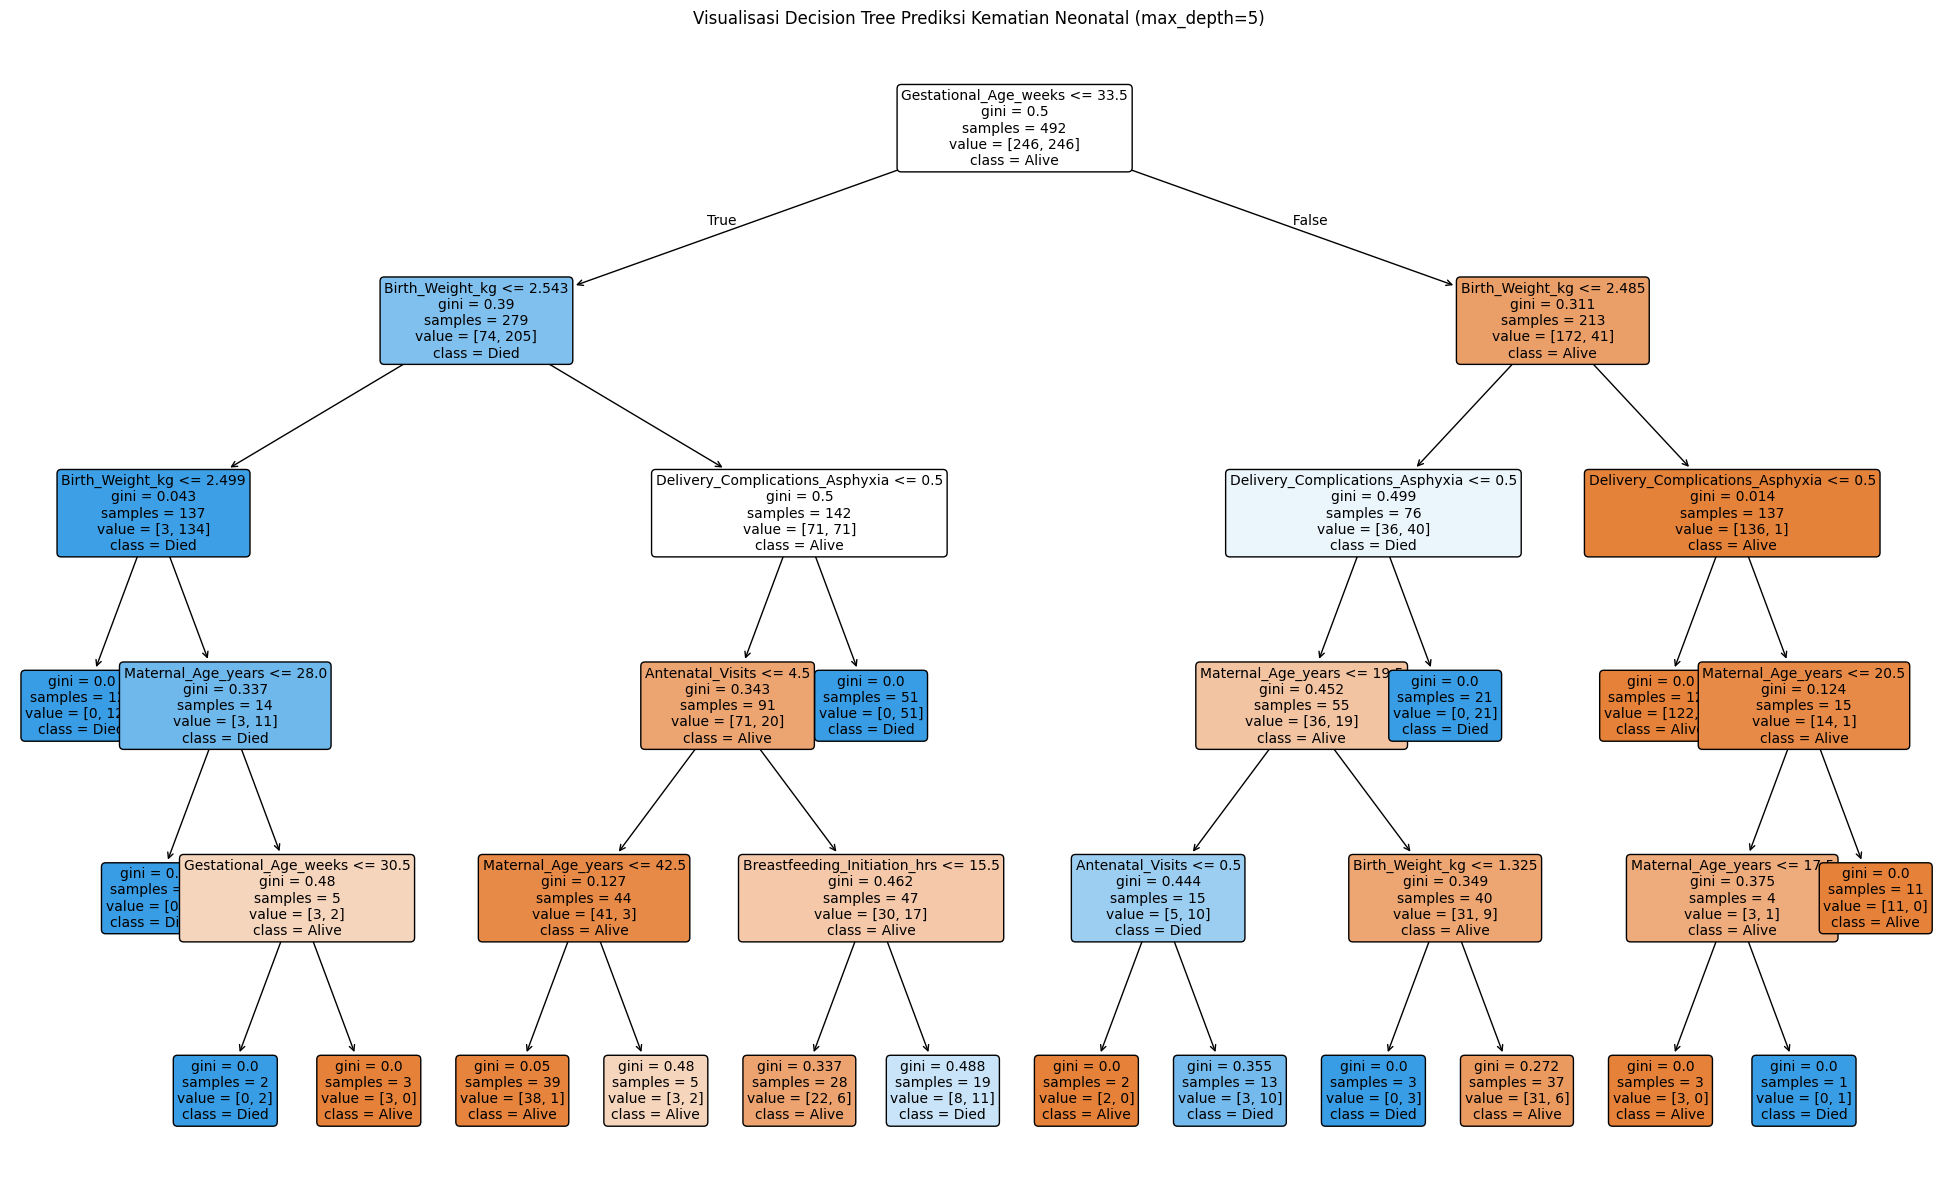

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

from imblearn.over_sampling import SMOTE

try:
    df = pd.read_excel('neonatal_mortality_dataset.xlsx')
except FileNotFoundError:
    print("ERROR: File 'neonatal_mortality_dataset.xlsx' tidak ditemukan.")
    raise # Penting: Berhenti eksekusi karena data utama tidak ditemukan

# KOREKSI MISSING VALUE DI Delivery_Complications
print("\n=====================================================")
print("Koreksi: Mengisi 307 Missing Value")
print("=====================================================")

# Cek nilai yang paling sering muncul (Mode)
mode_complication = df['Delivery_Complications'].mode()[0]
print(f"Nilai terbanyak (Mode) di Delivery_Complications adalah: {mode_complication}")

# Mengisi NaN (nilai hilang) dengan mode
df['Delivery_Complications'].fillna(mode_complication, inplace=True)

# Verifikasi: Cek lagi missing values (Harus 0)
print("\nVerifikasi Missing Values:")
print(df.isnull().sum())

# lanjut jika semua 0

print("=====================================================")
print("Langkah 1: Data Understanding dan Cek Awal")
print("=====================================================")
print("Jumlah Baris Data Awal:", len(df))
print("\nStatistik Deskriptif:")
print(df.describe(include='all'))
print("\nCek Missing Values:")
print(df.isnull().sum())
print("\nKeseimbangan Kelas Target Awal (Imbalance):")
# Output ini akan menunjukkan betapa tidak seimbangnya data sebelum SMOTE
print(df['Neonatal_Outcome'].value_counts())

# ==============================================================================
# 2. DATA PREPROCESSING (Langkah 2)
# ==============================================================================
print("\n=====================================================")
print("Langkah 2: Preprocessing Data (Encoding)")
print("=====================================================")

# A. Encoding Variabel Target (Alive/Died -> 0/1)
le = LabelEncoder()
df['Neonatal_Outcome'] = le.fit_transform(df['Neonatal_Outcome'])
# Cek urutan kelas: le.classes_[0] adalah 0, le.classes_[1] adalah 1
print(f"Kelas Target: 0 = {le.classes_[0]}, 1 = {le.classes_[1]}")

# B. One-Hot Encoding untuk Fitur Kategori
# Mengubah teks menjadi kolom biner (0 atau 1)
categorical_features = ['Delivery_Complications', 'Place_of_Delivery']
df_model = pd.get_dummies(df, columns=categorical_features, drop_first=False)

# Cek hasil encoding
print("\nKolom Setelah Encoding (Total Kolom):", len(df_model.columns))
print("Contoh Kolom Baru:", [col for col in df_model.columns if any(cat in col for cat in categorical_features)])

# ==============================================================================
# 3. PEMBAGIAN DATA (Langkah 3)
# ==============================================================================
print("\n=====================================================")
print("Langkah 3: Train Test Split (70% Latih, 30% Uji)")
print("=====================================================")

# Pisahkan Fitur (X) dan Target (y)
X = df_model.drop('Neonatal_Outcome', axis=1)
y = df_model['Neonatal_Outcome']

# Bagi data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Data Latih (Train) : {len(X_train)} baris")
print(f"Data Ujian (Test)  : {len(X_test)} baris")

# ==============================================================================
# 4. PENANGANAN IMBALANCE DENGAN SMOTE (Langkah 4)
# ==============================================================================
print("\n=====================================================")
print("Langkah 4: SMOTE (Hanya pada Data Latih)")
print("=====================================================")
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

print(f"Jumlah data Latih setelah SMOTE: {len(X_train_smote)} baris")
print("Keseimbangan Kelas Target di Data Latih (Setelah SMOTE):")
print(y_train_smote.value_counts())
# Sekarang jumlah 0 dan 1 harus sama

# ==============================================================================
# 5. MODELLING MACHINE LEARNING (Langkah 5)
# ==============================================================================
print("\n=====================================================")
print("Langkah 5: Modelling Decision Tree")
print("=====================================================")
from sklearn.tree import DecisionTreeClassifier

# Inisialisasi Model Decision Tree (Batasi kedalaman pohon/max_depth=5 untuk interpretasi mudah)
model = DecisionTreeClassifier(max_depth=5, random_state=42)

# Latih Model menggunakan data yang sudah di-SMOTE
model.fit(X_train_smote, y_train_smote)

# Prediksi pada data Ujian (X_test) yang ASLI (tanpa SMOTE)
y_pred = model.predict(X_test)

# ==============================================================================
# Menyimpan model
# ==============================================================================
print("\n=====================================================")
print("Menyimpan model")
print("=====================================================")

# 1. INSTALL LIBRARY UNTUK MENYIMPAN MODEL
!pip install joblib

import joblib
import pandas as pd
from sklearn.preprocessing import LabelEncoder
# Asumsi 'model' sudah dilatih dan 'X' adalah DataFrame fitur sebelum split

# 2. SIMPAN MODEL DECISION TREE
joblib.dump(model, 'model_neonatal_dt.joblib')
print("Model Decision Tree berhasil disimpan sebagai 'model_neonatal_dt.joblib'")

# 3. SIMPAN DAFTAR KOLOM FITUR (Penting untuk Streamlit)
# Ini memastikan urutan input di Streamlit sama persis dengan urutan saat pelatihan
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, 'feature_columns.joblib')
print("Daftar Fitur berhasil disimpan sebagai 'feature_columns.joblib'")

# 4. SIMPAN ENCODER UNTUK LABEL TARGET (Alive/Died)
# Asumsi 'le' (LabelEncoder) sudah dibuat di langkah 2
joblib.dump(le, 'label_encoder.joblib')
print("Label Encoder berhasil disimpan sebagai 'label_encoder.joblib'")

# ==============================================================================
# 6. EVALUASI MODEL (Langkah 6)
# ==============================================================================
print("\n=====================================================")
print("Langkah 6: Evaluasi Model pada Data Ujian (Test)")
print("=====================================================")

# A. Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model Decision Tree: {accuracy*100:.2f}%")

# B. Confusion Matrix (Tabel Kesalahan)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
# Baris 0: Prediksi Benar 'Alive', Prediksi Salah 'Died'
# Baris 1: Prediksi Salah 'Alive', Prediksi Benar 'Died'
print(cm)

# C. Classification Report (Precision, Recall, F1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
# ==============================================================================
# 7. INTERPRETASI (Langkah 7)
# ==============================================================================
print("\n=====================================================")
print("Langkah 7: Interpretasi (Untuk Insight Kesehatan)")
print("=====================================================")

# A. Feature Importance (Faktor Risiko Terpenting)
feature_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("TOP 5 FAKTOR RISIKO TERPENTING:")
print(feature_importance.head(5))

# B. Visualisasi Pohon Keputusan
plt.figure(figsize=(25,15))
plot_tree(model,
          feature_names=X.columns.tolist(),
          class_names=le.classes_,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Visualisasi Decision Tree Prediksi Kematian Neonatal (max_depth=5)")
plt.show()